# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [364]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.shape

(150, 4)

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [365]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 10)
X_train.shape

(90, 4)

#### 1.2. Обучите модель KNN

In [366]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3

model = KNeighborsClassifier(n_neighbors = n_neighbors)

model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 1.3. Проверьте качество работы модели

In [368]:
pred_train = model.predict(X_train)
display(pred_train, y_train)


array([0, 0, 1, 1, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 0, 1, 2, 1, 0, 2,
       1, 1, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 0,
       0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 2, 0,
       1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0,
       2, 0])

array([0, 0, 2, 1, 2, 0, 2, 0, 1, 1, 0, 2, 2, 2, 2, 2, 0, 1, 2, 1, 0, 2,
       1, 1, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 0,
       0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 2, 0,
       1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0,
       2, 0])

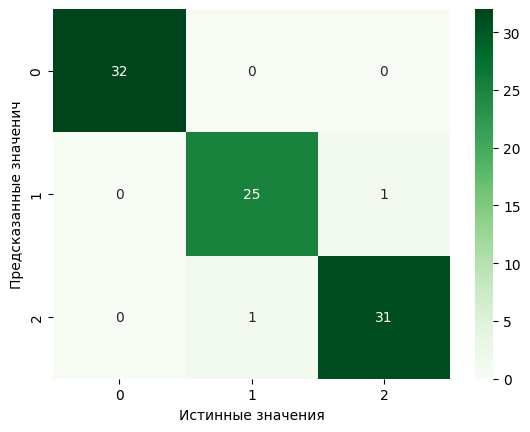

array([[32,  0,  0],
       [ 0, 25,  1],
       [ 0,  1, 31]])

In [369]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, pred_train)
sns.heatmap(cm, annot = True, cmap = 'Greens')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значенич')
plt.show()
cm

#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

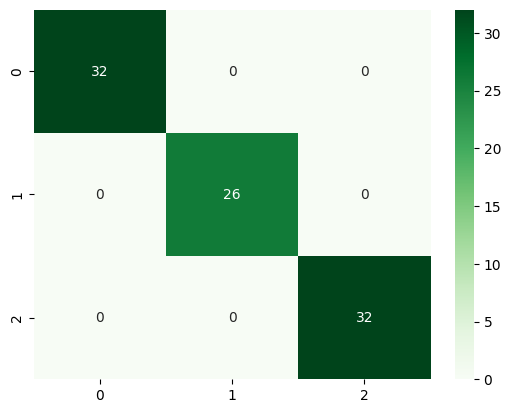

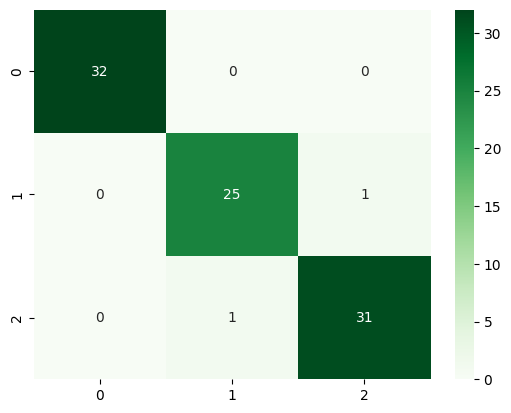

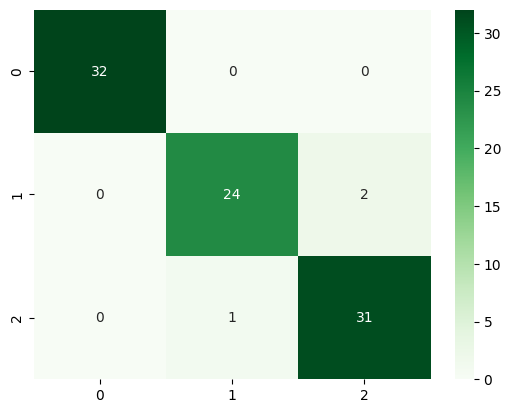

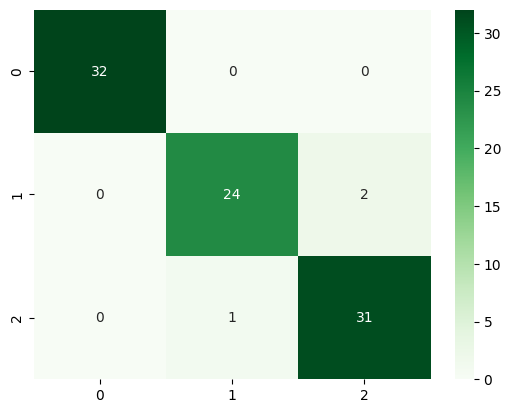

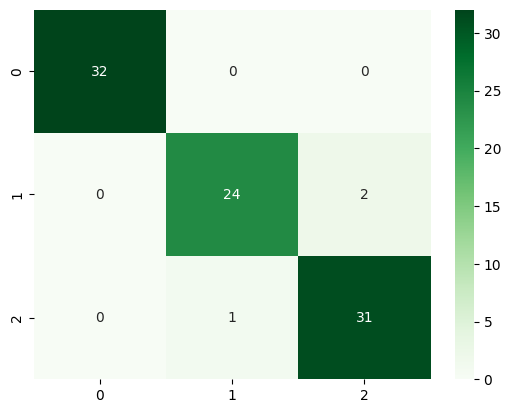

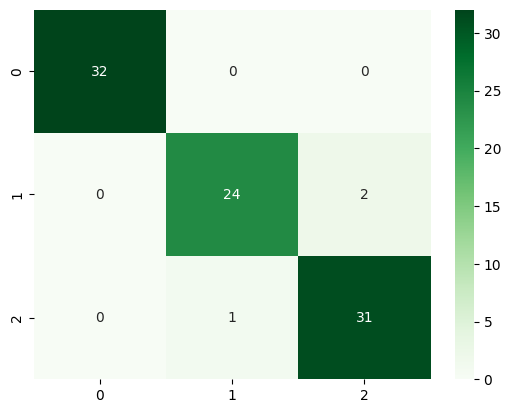


 Тестовая выборка: (самое оптимальное значеие k = 6) 



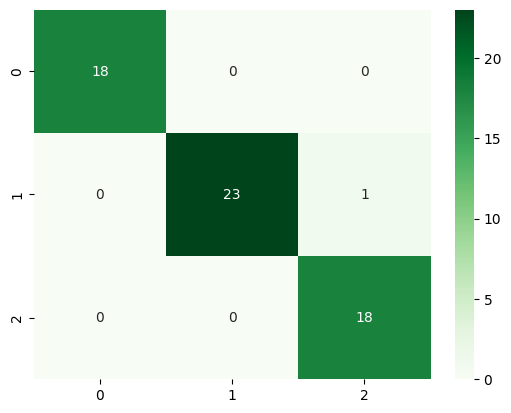

In [370]:

model = KNeighborsClassifier(n_neighbors = 1)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()

model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()

model = KNeighborsClassifier(n_neighbors = 5)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()

model = KNeighborsClassifier(n_neighbors = 7)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()

model = KNeighborsClassifier(n_neighbors = 9)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()

model = KNeighborsClassifier(n_neighbors = 11)
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
sns.heatmap(confusion_matrix(y_train, pred_train), annot = True, cmap = 'Greens')
plt.show()


print('\n', "Тестовая выборка: (самое оптимальное значеие k = 6)", '\n')
model = KNeighborsClassifier(n_neighbors = 6)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)
sns.heatmap(confusion_matrix(y_test, pred_test), annot = True, cmap = 'Greens')
plt.show()





### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [371]:
import random
random.seed(40)
idx_1 = random.randint(0, len(X_test))
test_dot_1 = X_test.iloc[idx_1]
true_label_1 = y_test[idx_1]

random.seed(84)
idx_2 = random.randint(0, len(X_test))
test_dot_2 = X_test.iloc[idx_2]
true_label_2 = y_test[idx_2]
print(test_dot_1, f': class {true_label_1}\n')
print(test_dot_2, f': class {true_label_2}\n')



sepal length (cm)    7.7
sepal width (cm)     3.8
petal length (cm)    6.7
petal width (cm)     2.2
Name: 117, dtype: float64 : class 2

sepal length (cm)    6.9
sepal width (cm)     3.1
petal length (cm)    4.9
petal width (cm)     1.5
Name: 52, dtype: float64 : class 1



#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [372]:
def count_distance(test_dot):
  distance_data = []
  for i in range(len(X_train)):
    distance_data.append({
        'train_idx': i,
        'dst': np.linalg.norm(X_train.iloc[i] - test_dot, ord = 2)
    })
  return pd.DataFrame(distance_data)

distances_data_1  = count_distance(test_dot_1)
distances_data_2  = count_distance(test_dot_2)



#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [373]:
print(distances_data_1.sort_values('dst').head(3), '\n')
print(distances_data_2.sort_values('dst').head(3))


    train_idx       dst
12         12  0.412311
14         14  0.818535
68         68  1.004988 

    train_idx       dst
22         22  0.264575
60         60  0.282843
67         67  0.316228


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [374]:
def nearest(distances_data, k_nearest):
    array = np.array([])
    for i in distances_data.sort_values('dst').head(k_nearest).index:
        array = np.append(array, y_train[i])
    
    result = np.argmax(np.bincount(array.astype('int64'))) 

    return result

pred_result_1 = nearest(distances_data_1, 3)
pred_result_2 = nearest(distances_data_2, 3)
print(pred_result_1, pred_result_2)


2 1


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [375]:
print(f"Предсказанные классы: {pred_result_1, pred_result_2}")
print(f"Исходные классы: {true_label_1, true_label_2}")

print("Значения сошлись:",[pred_result_1, pred_result_2] == [true_label_1, true_label_2])

Предсказанные классы: (np.int64(2), np.int64(1))
Исходные классы: (np.int64(2), np.int64(1))
Значения сошлись: True


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [376]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.shape

(20640, 8)

### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [377]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 10,
    test_size = 0.4
)
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5348,5.0151,33.0,4.804276,1.072368,1124.0,1.848684,34.05,-118.42
3064,1.8843,16.0,4.414747,1.039939,3078.0,4.728111,35.68,-119.22
14006,5.3920,52.0,6.870536,0.946429,535.0,2.388393,32.75,-117.18
15185,4.1279,7.0,7.508299,1.597510,1134.0,2.352697,32.96,-117.10
19138,4.6324,16.0,5.685410,1.060790,1938.0,2.945289,38.32,-122.69
...,...,...,...,...,...,...,...,...
9372,4.1250,37.0,5.109792,1.044510,648.0,1.922849,37.93,-122.53
7291,1.2059,18.0,2.537037,1.089744,1913.0,2.725071,33.98,-118.22
17728,5.5336,6.0,4.905336,0.965577,2160.0,3.717728,37.32,-121.79
7293,2.2059,35.0,2.748491,0.997988,2160.0,4.346076,33.98,-118.23


Затем нормализуйте данные:

In [378]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_test.columns]), columns=X_test.columns)

#### 3.2. Обучите модель KNN


In [379]:
from sklearn.neighbors import KNeighborsRegressor

n_neighbors = 7

model = KNeighborsRegressor(n_neighbors = n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 3.3. Проверьте качество работы модели

In [380]:
from sklearn import metrics

pred_test = model.predict(X_test)
# display(pred_test, y_test)
print('MSE:')
MSE = np.square(np.subtract(y_test, pred_test)).mean()
print(MSE)
print('R2 score:')
R2_score = metrics.r2_score(y_test, pred_test)
print(R2_score)

MSE:
0.40270854231188297
R2 score:
0.700026752647785


#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [381]:
# САМОЕ ОПТИМАЛЬНОЕ n_neighbors = 7

def knn_calculation(n_neighbors, X_train, y_train, X_test, y_test):
    model = KNeighborsRegressor(n_neighbors = n_neighbors)
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    print('MSE:')
    MSE = np.square(np.subtract(y_test, pred_test)).mean()
    print(MSE)
    print('R2 score:')
    R2_score = metrics.r2_score(y_test, pred_test)
    print(R2_score, '\n\n')

for i in range(1, 20):
    knn_calculation(i, X_train, y_train, X_test, y_test)





MSE:
0.5947946723372456
R2 score:
0.5569438672830074 


MSE:
0.46492291928211593
R2 score:
0.6536839346270484 


MSE:
0.43385201006612834
R2 score:
0.6768283196013491 


MSE:
0.4168171628532173
R2 score:
0.6895173934592567 


MSE:
0.4106720460136337
R2 score:
0.6940948246782375 


MSE:
0.4044428436308829
R2 score:
0.6987348903109172 


MSE:
0.40270854231188297
R2 score:
0.700026752647785 


MSE:
0.40342148988676985
R2 score:
0.6994956856930019 


MSE:
0.4029811843424822
R2 score:
0.6998236645413991 


MSE:
0.40276547773869803
R2 score:
0.6999843420627672 


MSE:
0.4035580248685172
R2 score:
0.699393982258511 


MSE:
0.4038922097494883
R2 score:
0.6991450515470208 


MSE:
0.40561293734653425
R2 score:
0.6978633001291561 


MSE:
0.4068608444797897
R2 score:
0.6969337475723427 


MSE:
0.40792169489253116
R2 score:
0.6961435315480237 


MSE:
0.40768965734231744
R2 score:
0.6963163738151523 


MSE:
0.40857154791962047
R2 score:
0.6956594630410122 


MSE:
0.4106781069085807
R2 score:
0.69409

### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [382]:
import random

random.seed(10)
idx_1 = random.randint(0, len(X_test))
test_dot_1 = X_test.iloc[idx_1]
true_test_1 = y_test[idx_1]

random.seed(20)
idx_2 = random.randint(0, len(X_test))
test_dot_2 = X_test.iloc[idx_2]
true_test_2 = y_test[idx_2]
print(test_dot_1, 'Истинный целевой признак: ', true_test_1, '\n\n')
print(test_dot_2, 'Истинный целевой признак: ', true_test_2)

MedInc        0.232762
HouseAge      0.764706
AveRooms      0.023338
AveBedrms     0.030795
Population    0.022369
AveOccup      0.003171
Latitude      0.155154
Longitude     0.598178
Name: 533, dtype: float64 Истинный целевой признак:  3.213 


MedInc        0.395477
HouseAge      0.960784
AveRooms      0.035304
AveBedrms     0.031230
Population    0.019118
AveOccup      0.003292
Latitude      0.161530
Longitude     0.604251
Name: 2477, dtype: float64 Истинный целевой признак:  5.00001


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [383]:
def count_distance_from(test_dot, X_y_train):
    distances_data = []
    for i in range(len(X_y_train)):
        distances_data.append({
            'train_idx': i,
            'dst': np.linalg.norm(X_y_train.iloc[i] - test_dot, ord = 2) 
        })
    return pd.DataFrame(distances_data)

distances_data_1 = count_distance_from(test_dot_1, X_train)
distances_data_2 = count_distance_from(test_dot_2, X_train)
distances_data_1

,train_idx,dst
0,0,0.158616
1,1,0.531497
2,2,0.317324
3,3,0.671284
4,4,0.788107
...,...,...
12379,12379,0.591292
12380,12380,0.470700
12381,12381,0.835753
12382,12382,0.157749


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [384]:
k_neighbours = 5
k_neighbours_1 = distances_data_1.sort_values('dst').head(k_neighbours)
k_neighbours_2 = distances_data_2.sort_values('dst').head(k_neighbours)
display(k_neighbours_1)
display(k_neighbours_2)


,train_idx,dst
9093,9093,0.013259
2956,2956,0.021421
1783,1783,0.023031
577,577,0.023444
8375,8375,0.024852


,train_idx,dst
449,449,0.027767
11122,11122,0.034344
3945,3945,0.034752
12152,12152,0.035591
11077,11077,0.039695


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [387]:
def nearest(distances_data, k_nearest):
    data = distances_data.sort_values('dst').head(k_nearest)
    array = 0
    for i in (data['train_idx']):
        array += y_train[i]
    return array / k_nearest
    
result_pred_1 = nearest(distances_data_1, k_neighbours)
result_pred_2 = nearest(distances_data_2, k_neighbours)
print(result_pred_1)
print(result_pred_2)

3.2020020000000002
4.360004


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [388]:
print('Предсазанное значение:', result_pred_1, 'Истинное значение', true_test_1)

print('Предсазанное значение:', result_pred_2, 'Истинное значение', true_test_2)

Предсазанное значение: 3.2020020000000002 Истинное значение 3.213
Предсазанное значение: 4.360004 Истинное значение 5.00001


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [389]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [390]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [398]:
New_X = X.loc[:, ['sepal length (cm)','petal width (cm)']]
New_X

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>

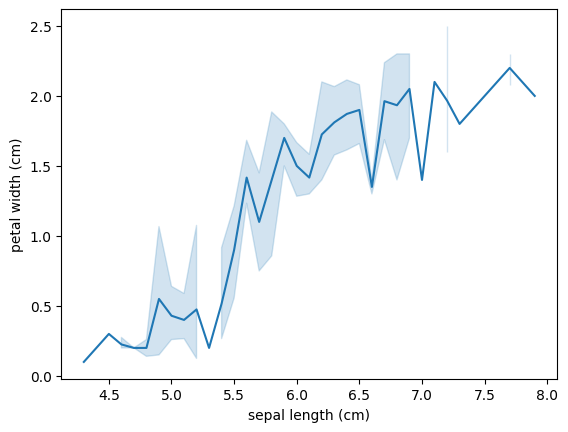

In [400]:
sns.lineplot(data = New_X, x = 'sepal length (cm)', y = 'petal width (cm)')


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [403]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 10, test_size = 0.4)
X_train.shape

(90, 4)

#### 1.2. Обучите модель KNN на 50 соседях

In [543]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50

model = KNeighborsClassifier(n_neighbors = n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 1.3. Проверьте качество работы модели

array([0, 0, 1, 0, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 0, 1, 2, 1, 0, 2,
       2, 1, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 0,
       0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 2, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0,
       1, 2, 2, 2, 0, 1, 2, 2, 1, 2, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0,
       2, 0])

array([0, 0, 2, 1, 2, 0, 2, 0, 1, 1, 0, 2, 2, 2, 2, 2, 0, 1, 2, 1, 0, 2,
       1, 1, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 2, 2, 1, 0,
       0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 2, 0,
       1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0,
       2, 0])

<Axes: >

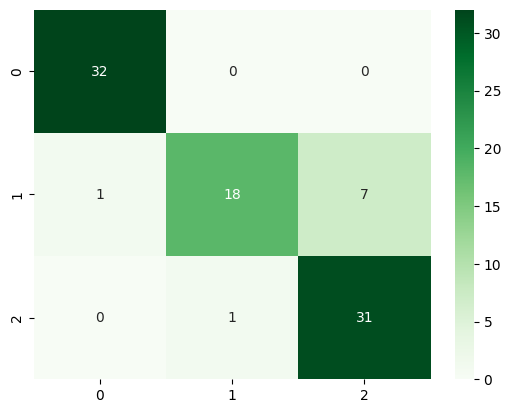

In [544]:
from sklearn.metrics import confusion_matrix

pred_train = model.predict(X_train)
display(pred_train, y_train)

cm = confusion_matrix(y_train, pred_train)
sns.heatmap(data = cm, annot = True, cmap = 'Greens')


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [545]:
random.seed(42)
idx_1 = random.randint(0, X_test.shape[0])
random_object = X_test.iloc[idx_1]
true_object = y_test[idx_1]
print("Рандомный обьект из X_test:\n", random_object)




Рандомный обьект из X_test:
 sepal length (cm)    5.0
sepal width (cm)     3.4
petal length (cm)    1.6
petal width (cm)     0.4
Name: 26, dtype: float64


#### 1.5. Выберите топ  k  соседей


In [546]:
def count_distance(tester, X_or_y_test):
    distances_data = []
    for i in range(X_or_y_test.shape[0]):
        distances_data.append({
            'idx': i,
            'dst': np.linalg.norm(X_or_y_test.iloc[i] - tester, ord = 2)
        })
    return pd.DataFrame(distances_data)

In [547]:
distances_data_idx_1 = count_distance(random_object, X_train)
distances_data_idx_1 = distances_data_idx_1.sort_values('dst').head(5)
distances_data_idx_1

,idx,dst
46,46,0.200000
31,31,0.223607
33,33,0.264575
44,44,0.282843
80,80,0.316228


#### 1.6. Выведите финальное предсказание для этого объекта

In [550]:
def nearest(distances_data):
    array = y_train[distances_data.index]
    result = np.argmax(np.bincount(array.astype('int64'))) 
    return result
pred_value = nearest(distances_data_idx_1)
pred_value

np.int64(0)

#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [551]:
display(f"Предсказанное значение: {pred_value}, Истинное: {true_object}")


'Предсказанное значение: 0, Истинное: 0'

#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

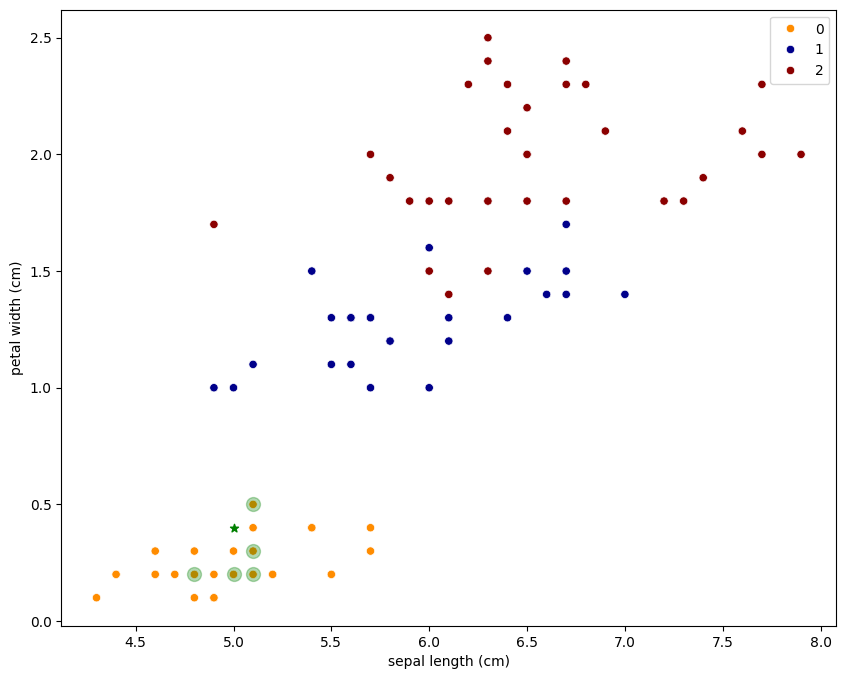

In [575]:
cmap_bold = ['darkorange', 'darkblue', 'darkred']

plt.figure(figsize = (10, 8))
sns.scatterplot(x = X_train['sepal length (cm)'], y = X_train['petal width (cm)'], hue = y_train, palette=cmap_bold)
plt.scatter(x = X_train.iloc[distances_data_idx_1.index]['sepal length (cm)'], y = X_train.iloc[distances_data_idx_1.index]['petal width (cm)'],
        c = 'g',
        alpha = 0.3,
        s = 100,
        label='test dot'
)
plt.scatter(x = random_object['sepal length (cm)'], y = random_object['petal width (cm)'], c = 'g', marker = "*")


### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [554]:
n_neighbors = 20
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 2.2. Проверьте качество работы модели


array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 1, 0,
       1, 0, 1, 2, 2, 2, 1, 2, 1, 1, 1, 0, 0, 1, 0, 2])

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 1, 0,
       1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0, 0, 1, 0, 2])

<Axes: >

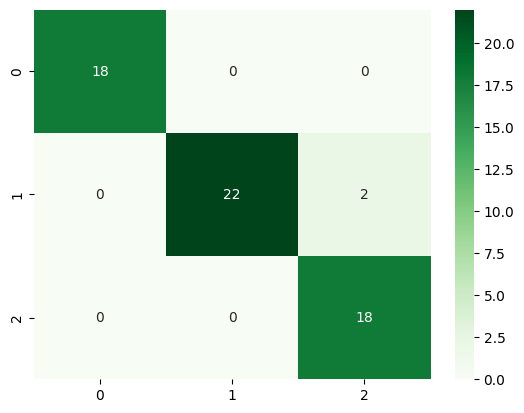

In [555]:
pred_test = model.predict(X_test)
display(pred_test, y_test)

from sklearn.metrics import confusion_matrix

cm =confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot = True, cmap = 'Greens')

#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [556]:
random.seed(42)
idx_1 = random.randint(0, X_test.shape[0])
random_object = X_test.iloc[idx_1]
true_object = y_test[idx_1]

def count_distance(tester, X_or_y_test):
    distances_data = []
    for i in range(X_or_y_test.shape[0]):
        distances_data.append({
            'idx': i,
            'dst': np.linalg.norm(X_or_y_test.iloc[i] - tester, ord = 2)
        })
    return pd.DataFrame(distances_data)

distances_data = count_distance(random_object, X_train)
distances_data

,idx,dst
0,0,0.412311
1,1,0.547723
2,2,3.304542
3,3,1.808314
4,4,4.793746
...,...,...
85,85,3.926831
86,86,2.328089
87,87,1.224745
88,88,5.118594


#### 2.4. Выберите топ  k  соседей


In [557]:
distances_data = distances_data.sort_values('dst').head(5)
distances_data['label'] = y_train[distances_data['idx']]
distances_data

,idx,dst,label
46,46,0.200000,0
31,31,0.223607,0
33,33,0.264575,0
44,44,0.282843,0
80,80,0.316228,0


#### 2.5. Рассчитайте вес для каждого соседа

In [558]:
distances_data['weight'] = 1 / distances_data['dst']
distances_data = distances_data.sort_values('weight')
distances_data

,idx,dst,label,weight
80,80,0.316228,0,3.162278
44,44,0.282843,0,3.535534
33,33,0.264575,0,3.779645
31,31,0.223607,0,4.472136
46,46,0.200000,0,5.000000


#### 2.6. Выведите финальное предсказание для этого объекта

In [562]:
display(f"Вес для класса 0 - {distances_data[distances_data['label'] == 0]['weight'].sum()}",
        f"Вес для класса 1 - {distances_data[distances_data['label'] == 1]['weight'].sum()}",
        f"Вес для класса 2 - {distances_data[distances_data['label'] == 2]['weight'].sum()}")
distances_data['label'].value_counts()

'Вес для класса 0 - 19.949592251192968'

'Вес для класса 1 - 0.0'

'Вес для класса 2 - 0.0'

label
0    5
Name: count, dtype: int64

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [569]:
print(f"истинное значение: {true_object}, предсказанное 0")

истинное значение: 0, предсказанное 0


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

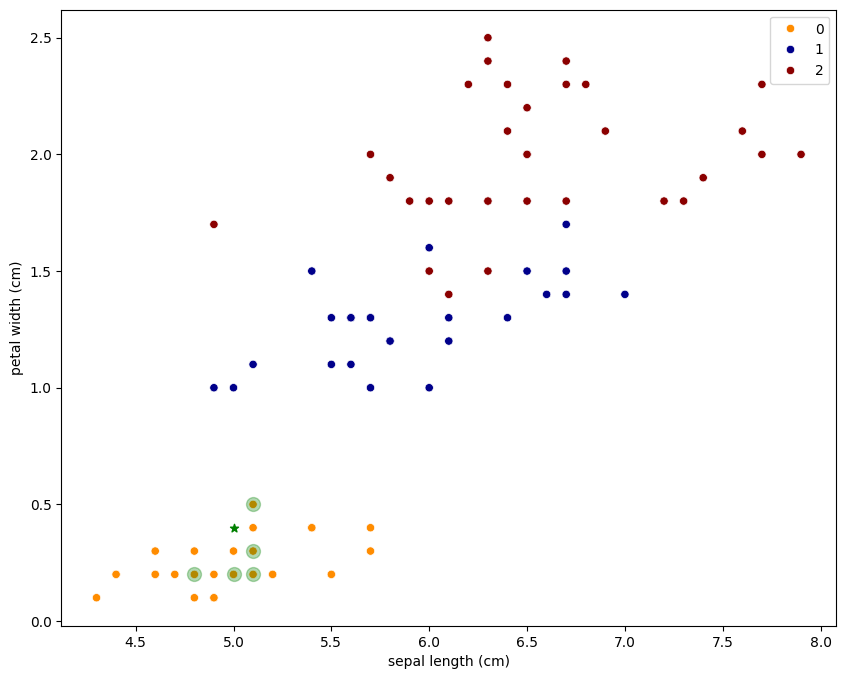

In [574]:
cmap_bold = ['darkorange', 'darkblue', 'darkred']

plt.figure(figsize = (10, 8))
sns.scatterplot(x = X_train['sepal length (cm)'], y = X_train['petal width (cm)'], hue = y_train, palette=cmap_bold)
plt.scatter(x = X_train.iloc[distances_data.index]['sepal length (cm)'], y = X_train.iloc[distances_data.index]['petal width (cm)'],
        c = 'g',
        alpha = 0.3,
        s = 100,
        label='test dot'
)
plt.scatter(x = random_object['sepal length (cm)'], y = random_object['petal width (cm)'], c = 'g', marker = "*")


## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [2]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

### Возьмите только признак MedInc и 1000 первых строк

In [2]:
medinc = X['MedInc'].head(1000)


### Отрисуйте данные на графике

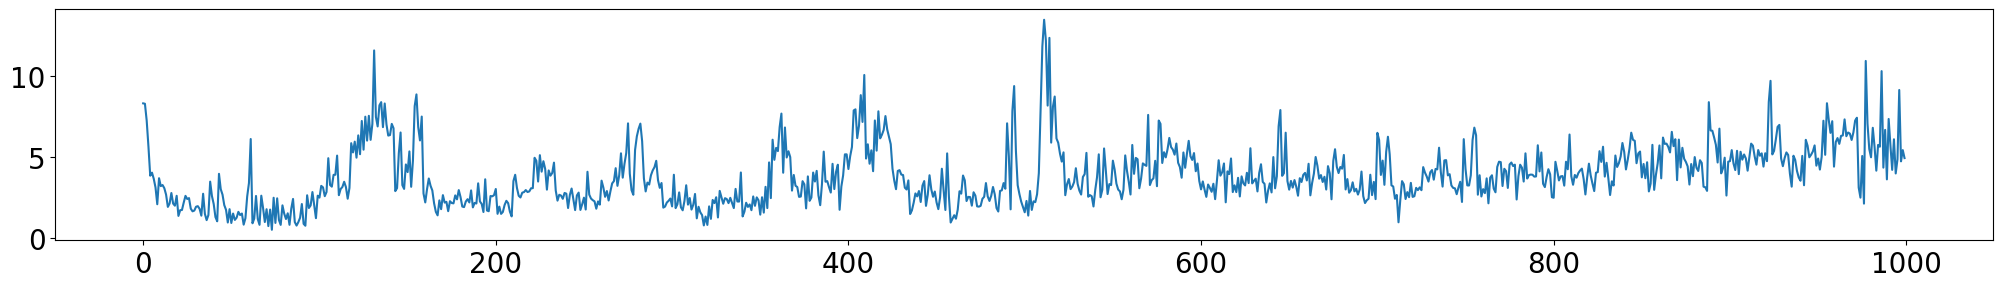

In [3]:
from matplotlib import pyplot as plt

array = np.array([i for i in range(medinc.shape[0])])

plt.figure(figsize = (25, 3))
plt.tick_params(labelsize = 20)
plt.plot(array, medinc)
plt.show()

### **4. KNN из sklearn**

Выполнить нормализацию данных

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

#### 4.1. Разбейте данные на обучение и тест

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 10)
X_train.shape


(12384, 8)

#### 4.2. Обучите модель KNN на 100 соседях


In [6]:
from sklearn.neighbors import KNeighborsRegressor

n_neighbors = 100

model = KNeighborsRegressor(n_neighbors = n_neighbors)

model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",100
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 4.3. Проверьте качество работы модели


In [7]:
from sklearn import metrics

pred_train = model.predict(X_train)
display(pred_train, y_train)

R2_score = metrics.r2_score(y_train, pred_train)
print("R2_score: ", R2_score)


array([2.8535606, 1.4710401, 3.379641 , ..., 2.2928401, 1.7042   ,
       1.8290301], shape=(12384,))

array([5.00001, 0.552  , 4.085  , ..., 2.419  , 1.5    , 1.911  ],
      shape=(12384,))

R2_score:  0.6526155554391098


#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [8]:
import random

def count_distance(test_or_train_dot):
    distance_data = []
    for i in range(len(X_train)):
        distance_data.append({
            'train_idx': i,
            'dst': np.linalg.norm(X_train[i] - test_or_train_dot, ord = 2)
        })
    return pd.DataFrame(distance_data)

random.seed(42)
idx_1 = random.randint(0, len(X_test) + 1)
element_1 = X_test[idx_1]
distances_data = count_distance(element_1).sort_values('dst')
distances_data



,train_idx,dst
7540,7540,0.420376
3685,3685,0.440696
183,183,0.444125
11362,11362,0.475288
9737,9737,0.503382
...,...,...
776,776,31.537608
8334,8334,37.695279
553,553,48.527340
573,573,57.677380


#### 4.5. Выберите топ  k  соседей


In [9]:
k_neighbours = 10
distances_data_k_neighbours = distances_data.head(k_neighbours).index
distances_data_k_neighbours

Index([7540, 3685, 183, 11362, 9737, 8484, 8412, 11931, 8740, 6199], dtype='int64')

#### 4.6. Выведите финальное предсказание для этого объекта

In [10]:
pred_x = y_train[distances_data_k_neighbours].mean()
pred_x

np.float64(0.9036)

#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [11]:
print(f'Предсказанное значение: {pred_x}, истинное значение: {y_test[idx_1]}')


Предсказанное значение: 0.9036, истинное значение: 0.542


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

<Axes: >

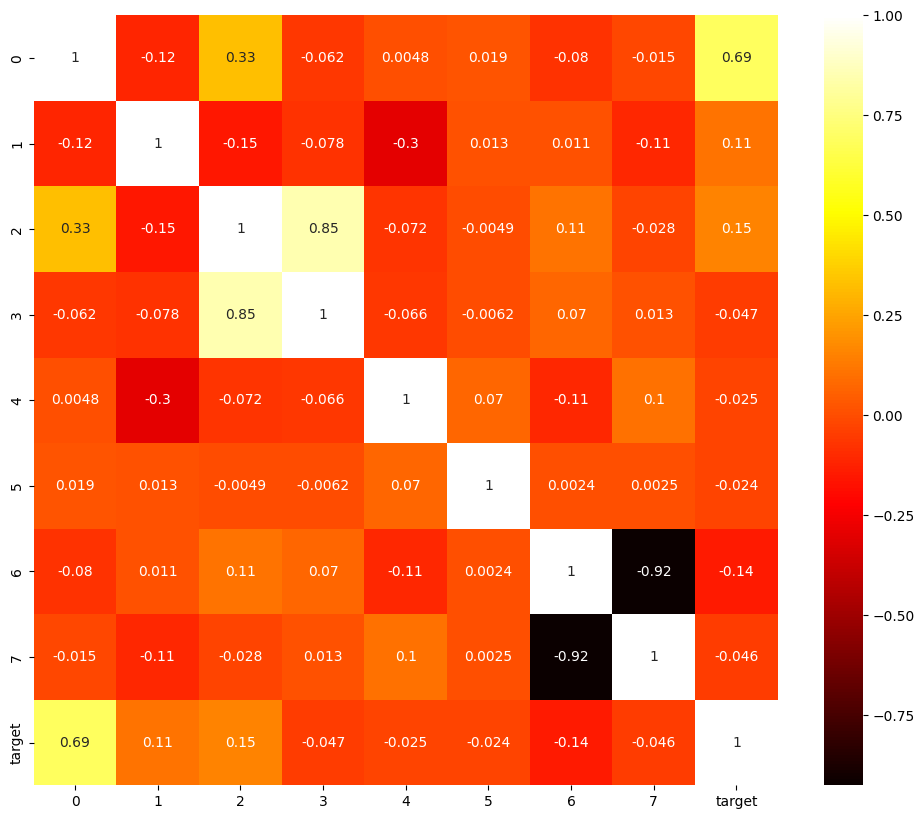

In [12]:
import seaborn as sns
df = pd.DataFrame(X).copy()
df['target'] = pd.Series(y)
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='hot')


Так как в задании не было указанно о снижении размерности датасета, то будем строить 3Д график по трем самым влияющим на целевой признак признакам

In [20]:
!pip install --upgrade nbformat

^C
Traceback (most recent call last):
  File "<frozen importlib._bootstrap_external>", line 1437, in _path_importer_cache
KeyError: '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/html'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/bin/pip", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pip/_internal/cli/main.py", line 47, in main
    from pip._internal.cli.autocompletion import autocomplete
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pip/_internal/cli/autocompletion.py", line 12, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pip/_internal/cli/main_parser.py", line 11, in <module>
    from 

In [13]:
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.renderers.default = 'browser'
price_categories = pd.cut(y_train, bins=3, labels=['MedInc', 'HouseAge', 'Rooms'])

x = X_train[:, 0]
y = X_train[:, 1]
z = X_train[:, 2]
colors = ['red', 'orange', 'green']

points = X_train[distances_data_k_neighbours]

fig = px.scatter_3d(x=x, y=y, z=z, color=price_categories, color_discrete_sequence=colors)
fig.update_traces(marker=dict(size=2))
fig.add_trace(go.Scatter3d(x = [element_1[0]], y = [element_1[1]], z = [element_1[2]],mode='markers', marker=dict(size=5, color='black')))
fig.add_trace(go.Scatter3d(x = points[:,0], y = points[:,1], z = points[:,2],mode='markers', marker=dict(size=5, color='blue', opacity = 0.6)))
fig.show()



### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [14]:
n_neighbors = 20
model = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

In [15]:
model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### 5.2. Проверьте качество работы модели


In [16]:
from sklearn.metrics import r2_score
pred_test = model.predict(X_test)
display(pred_test, y_test)
score = r2_score(y_test, pred_test)
print("R2_score:", score)

random.seed(40)
idx_1 = random.randint(0, X_test.shape[0])
random_test_object = X_test[idx_1]
true_random = y_test[idx_1]

pred_test = model.predict([random_test_object])
display(pred_test, true_random)

array([2.44124721, 2.54323314, 2.2771603 , ..., 3.78330067, 2.90104066,
       1.86482985], shape=(8256,))

array([1.674, 3.541, 1.602, ..., 1.969, 3.2  , 1.117], shape=(8256,))

R2_score: 0.6895310840481444


array([4.06412446])

np.float64(4.199)

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [17]:

def count_distance(test_or_train_dot):
    distance_data = []
    for i in range(len(X_train)):
        distance_data.append({
            'train_idx': i,
            'dst': np.linalg.norm(X_train[i] - test_or_train_dot, ord = 2)
        })
    return pd.DataFrame(distance_data)


element_1 = X_test[idx_1]
distances_data = count_distance(random_test_object).sort_values('dst')
distances_data




,train_idx,dst
9155,9155,0.358939
11276,11276,0.366428
979,979,0.430008
5990,5990,0.499797
11352,11352,0.542527
...,...,...
776,776,30.629153
8334,8334,37.152421
553,553,48.366280
573,573,57.600160


#### 5.4. Выберите топ  k  соседей


In [18]:
distances_data_top5 = distances_data.sort_values('dst').head(5)
distances_data_top5

,train_idx,dst
9155,9155,0.358939
11276,11276,0.366428
979,979,0.430008
5990,5990,0.499797
11352,11352,0.542527


#### 5.5. Рассчитайте вес для каждого соседа

In [19]:
distances_data_top5['weight'] = 1/distances_data_top5['dst']
distances_data_top5

,train_idx,dst,weight
9155,9155,0.358939,2.785991
11276,11276,0.366428,2.729048
979,979,0.430008,2.325537
5990,5990,0.499797,2.000813
11352,11352,0.542527,1.843225


#### 5.6. Выведите финальное предсказание для этого объекта

In [20]:
pred_x = y_train[distances_data_top5.index].mean()
pred_x

np.float64(3.957202)

#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [21]:
display(pred_x, true_random)


np.float64(3.957202)

np.float64(4.199)

#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

In [22]:
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.renderers.default = 'browser'
price_categories = pd.cut(y_train, bins=3, labels=['MedInc', 'HouseAge', 'Rooms'])

x = X_train[:, 0]
y = X_train[:, 1]
z = X_train[:, 2]
colors = ['red', 'orange', 'green']

points = X_train[distances_data_top5.index]

fig = px.scatter_3d(x=x, y=y, z=z, color=price_categories, color_discrete_sequence=colors)
fig.update_traces(marker=dict(size=2))
fig.add_trace(go.Scatter3d(x = [element_1[0]], y = [element_1[1]], z = [element_1[2]],mode='markers', marker=dict(size=5, color='black')))
fig.add_trace(go.Scatter3d(x = points[:,0], y = points[:,1], z = points[:,2],mode='markers', marker=dict(size=5, color='blue', opacity = 0.6)))
fig.show()



## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [138]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 4.3 MB/s  0:00:00 eta 0:00:01


In [26]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

clf = XGBRegressor(random_state = 2021)
parametrs = { 'n_estimators': [100, 200, 500],
              'max_depth': [3, 6, 9],
              'gamma': [0.01, 0.1], 
              'learning_rate': [0.001, 0.01, 0.1, 1]}

grid = GridSearchCV(clf, parametrs, cv=5, n_jobs = -1)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'gamma': 0.01, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}


In [30]:
from sklearn.neighbors import KNeighborsRegressor


param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

random_search_ridge = GridSearchCV(KNeighborsRegressor(), param_grid=param_grid, cv=5)
random_search_ridge.fit(X_train, y_train)

random_search_ridge.best_params_

array([1.674, 3.541, 1.602, ..., 1.969, 3.2  , 1.117], shape=(8256,))

array([2.459466  , 2.74400069, 2.33678695, ..., 3.77195879, 3.17043406,
       1.95489475], shape=(8256,))

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
y_pre = random_search_ridge.predict(X_test)
display(y_test, y_pre)
print('R2_score: ', r2_score(y_pred=y_pre, y_true=y_test))
print('MAE: ', mean_absolute_error(y_pred=y_pre, y_true=y_test))
print('RMSE: ', root_mean_squared_error(y_pred=y_pre, y_true=y_test))
print('MSE: ', mean_squared_error(y_pred=y_pre, y_true=y_test))


array([1.674, 3.541, 1.602, ..., 1.969, 3.2  , 1.117], shape=(8256,))

array([2.459466  , 2.74400069, 2.33678695, ..., 3.77195879, 3.17043406,
       1.95489475], shape=(8256,))

R2_score:  0.6956250647131839
MAE:  0.4351751000995725
RMSE:  0.6392321386156927
MSE:  0.40861772703919214
